In [1]:
# ===== 셀 1: 준비물 가져오기 (도구 불러오기) =====

import os                              # 컴퓨터의 환경설정(.env 값 등)을 읽기 위한 도구
import requests                        # 인터넷 주소에 데이터를 요청(다운로드)하는 도구
import pandas as pd                    # 표(엑셀 같은 형태)로 데이터를 다루는 도구. 보통 'pd'라는 별명으로 씀
import xml.etree.ElementTree as ET     # XML 형식의 데이터를 분석(파싱)하는 도구. 별명은 'ET'
import matplotlib.pyplot as plt        # 그래프를 그리는 도구. 별명은 'plt'
import matplotlib                      # 그래프 도구의 본체 (글꼴 설정 등에 사용)
from dotenv import load_dotenv         # .env 파일을 읽어오는 도구

# 그래프에 한글이 깨지지 않도록 글꼴을 'Malgun Gothic'(맑은 고딕)으로 지정
matplotlib.rcParams["font.family"] = "Malgun Gothic"
# 그래프에서 음수(-) 기호가 깨지지 않도록 하는 설정
matplotlib.rcParams["axes.unicode_minus"] = False

load_dotenv()                          # .env 파일을 읽어서 안의 값들을 사용할 수 있게 준비
SERVICE_KEY = os.getenv("KOPIS_SERVICE_KEY")   # .env 안의 KOPIS_SERVICE_KEY 값을 꺼내서 변수에 저장

print("서비스 키 로드됨:", bool(SERVICE_KEY))   # 키를 잘 불러왔는지 확인 (True면 성공)

서비스 키 로드됨: True


In [2]:
# ===== 셀 2: 오늘 '공연중'인 공연 데이터를 인터넷에서 모두 가져오기 =====

from datetime import date             # 오늘 날짜를 알아내기 위한 도구

BASE_URL = "http://www.kopis.or.kr/openApi/restful/pblprfr"   # 데이터를 요청할 기본 주소
today = date.today().strftime("%Y%m%d")   # 오늘 날짜를 '20260617' 같은 형태의 글자로 만듦

# 영어로 된 컬럼 이름을 한글로 바꿔주는 사전(번역표). 왼쪽:원래이름 → 오른쪽:한글이름
col_map = {
    "mt20id": "공연ID", "prfnm": "공연명",
    "prfpdfrom": "시작일", "prfpdto": "종료일",
    "fcltynm": "공연시설명", "poster": "포스터",
    "area": "지역", "genrenm": "장르",
    "openrun": "오픈런", "prfstate": "공연상태",
}

rows = []                             # 가져온 공연들을 하나씩 담아둘 빈 목록(리스트)
page = 1                              # 현재 몇 번째 페이지를 요청 중인지 (1페이지부터 시작)

while True:                           # 더 이상 데이터가 없을 때까지 페이지를 넘기며 반복
    params = {                        # 서버에 보낼 조회 조건들(질문 내용)을 모아둔 사전
        "service": SERVICE_KEY,       # 내 서비스 키 (신분증 역할)
        "stdate": today,              # 조회 시작일 = 오늘
        "eddate": today,              # 조회 종료일 = 오늘  → 오늘 하는 공연만
        "prfstate": "02",             # 공연 상태 코드. 02는 '공연중'을 의미
        "cpage": page,                # 가져올 페이지 번호
        "rows": 100,                  # 한 페이지에 최대 100건까지 요청 (이 API의 최대값)
    }
    res = requests.get(BASE_URL, params=params)   # 위 조건으로 서버에 데이터 요청 → 응답을 res에 저장
    res.encoding = "utf-8"            # 응답 글자를 한글이 깨지지 않는 방식(utf-8)으로 읽도록 설정
    dbs = ET.fromstring(res.text).findall("db")   # 응답(XML)을 분석해서 공연 하나하나(db)를 목록으로 뽑음

    # 공연 하나(db)의 내부 항목들을 {이름: 값} 형태로 바꿔서 rows에 추가
    rows += [{c.tag: c.text for c in db} for db in dbs]

    if len(dbs) < 100:               # 이번 페이지의 결과가 100건보다 적으면 = 마지막 페이지라는 뜻
        break                        # 반복을 멈춤
    page += 1                        # 아니면 다음 페이지 번호로 +1 하고 계속 반복

df = pd.DataFrame(rows).rename(columns=col_map)   # 모은 데이터를 표(df)로 만들고 컬럼 이름을 한글로 변경

print(f"기준일: {today}")                          # 어떤 날짜 기준인지 출력
print(f"공연중 데이터: {len(df)}건 ({page}페이지)")   # 총 몇 건을 몇 페이지에 걸쳐 가져왔는지 출력

기준일: 20260617
공연중 데이터: 338건 (4페이지)


In [3]:
# ===== 셀 3: 모은 데이터를 표로 확인하기 =====

# df 표에서 보고 싶은 컬럼만 골라서, 맨 위 10줄(head(10))만 보여줌
df[["공연명", "장르", "공연시설명", "지역", "시작일", "종료일", "공연상태"]].head(10)

,공연명,장르,공연시설명,지역,시작일,종료일,공연상태
0,아기돼지 삼형제 [의정부],뮤지컬,우리소극장 [의정부],경기도,2026.05.23,2026.07.19,공연중
1,제39회 성라자로마을 자선음악회: 그대있음에 [성남],복합,성남아트센터,경기도,2026.06.17,2026.06.17,공연중
2,홍진호의 Way Back Home 첼로 리사이틀,서양음악(클래식),평창동일번지 아트하우스,서울특별시,2026.06.17,2026.08.12,공연중
3,수요일에 만나는 내 집 앞 예술의전당 (영상화) (6월),복합,부평문화사랑방,인천광역시,2026.06.10,2026.06.24,공연중
4,"다시보는 공연봄날, 음악으로 빚은 동화콘서트, 집으로",서양음악(클래식),세종문화회관,서울특별시,2026.06.17,2026.06.21,공연중
5,바리톤 고성현과 함께하는 모란이 피는 어느 날! 6월의 보훈에 헌정하며 [수원],서양음악(클래식),경기아트센터(구. 경기도문화의전당),경기도,2026.06.17,2026.06.17,공연중
6,"형, 이거 나만 불편해?",연극,소극장 혜화당 (구. 까망소극장),서울특별시,2026.06.17,2026.06.21,공연중
7,"제34회 젊은연극제, 모조인생 [천장산 우화극장]",연극,성북정보도서관,서울특별시,2026.06.16,2026.06.17,공연중
8,온리원 학교 [부산],서커스/마술,초록마술극장,부산광역시,2026.06.13,2026.07.05,공연중
9,레미제라블 [진도],연극,진도향토문화회관,전라남도,2026.06.17,2026.06.17,공연중


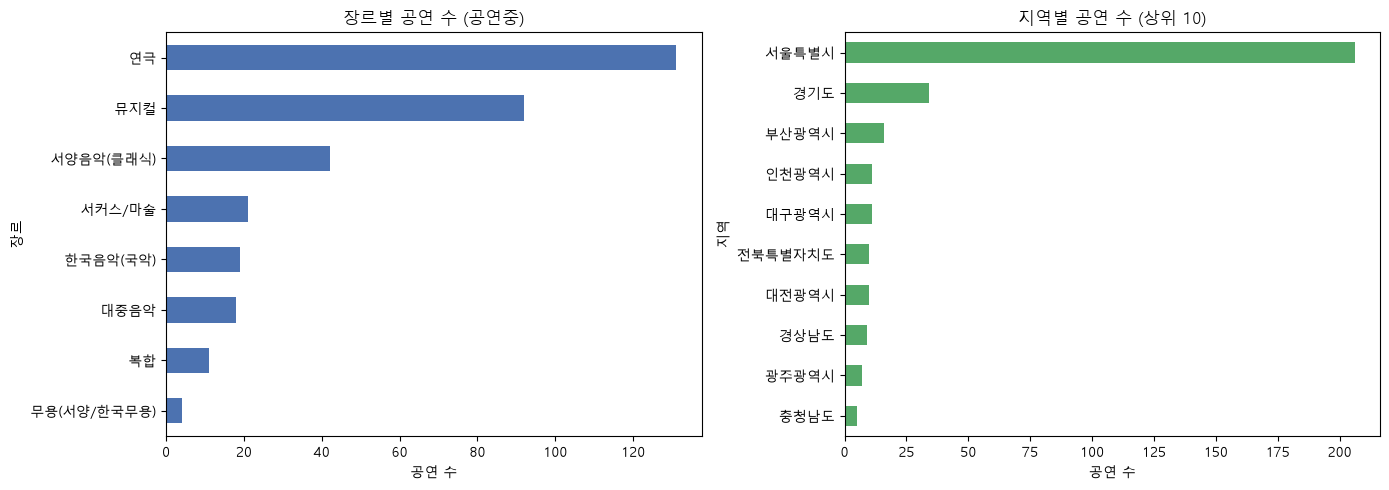

In [4]:
# ===== 셀 4: 데이터를 그래프로 그려서 한눈에 보기 =====

# 그래프 그릴 도화지를 준비. 가로로 1행 2열(그래프 2개), 전체 크기는 가로14 세로5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 왼쪽 그래프(axes[0]): 장르별 공연 수 ---
df["장르"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
# value_counts(): 장르별로 몇 개인지 세기 / kind="barh": 가로 막대그래프 / color: 막대 색
axes[0].set_title("장르별 공연 수 (공연중)")   # 그래프 제목
axes[0].set_xlabel("공연 수")                  # 가로축 이름
axes[0].invert_yaxis()                        # 가장 많은 항목이 위로 오도록 위아래 뒤집기

# --- 오른쪽 그래프(axes[1]): 지역별 공연 수 상위 10개 ---
df["지역"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#55A868")
# head(10): 가장 많은 지역 10개만 / 초록색 가로 막대그래프
axes[1].set_title("지역별 공연 수 (상위 10)")   # 그래프 제목
axes[1].set_xlabel("공연 수")                   # 가로축 이름
axes[1].invert_yaxis()                         # 가장 많은 항목이 위로 오도록 뒤집기

plt.tight_layout()   # 두 그래프가 서로 겹치지 않게 간격을 자동 정리
plt.show()           # 완성된 그래프를 화면에 표시